# EDA — Procura, Geografia, Demografia e Origem Escolar dos candidatos
vazios por coluna, procura por curso, validação cruzada de códigos,
geografia (província/distrito), estrangeiros, demografia (sexo/idade/estado civil), escola de
origem, ano de conclusão do secundário, local de exame, e uma síntese final de insights.

In [81]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [82]:
import unicodedata
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

OUTPUT_DIR = Path('../outputs/eda_procura_demografia')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def normalizar_texto(valor):
    if pd.isna(valor):
        return ''
    texto = unicodedata.normalize('NFKD', str(valor))
    texto = ''.join(caractere for caractere in texto if not unicodedata.combining(caractere))
    return ' '.join(texto.casefold().split())


def chave_categoria(valor):
    return normalizar_texto(valor)


def salvar_grafico(fig, nome_arquivo, dpi=300):
    caminho = OUTPUT_DIR / nome_arquivo
    fig.savefig(caminho, dpi=dpi, bbox_inches='tight')
    return caminho


def exportar_csv(df, nome_arquivo, index=False):
    caminho = OUTPUT_DIR / nome_arquivo
    df.to_csv(caminho, index=index)
    return caminho


df_candidatos = pd.read_parquet('../data/processed/candidatos_uem.parquet')
df_cursos = pd.read_excel('../data/raw/Cursos_UEM_2026.xlsx')

print(f'Linhas: {len(df_candidatos):,}')
print(f'Colunas: {len(df_candidatos.columns)}')
print('Prévia anonimizada:')
display(df_candidatos[['Sexo', 'ProvNasc', 'ProvRes', 'UEM_Opc1', 'UEM_Opc2']].head())

Linhas: 26,798
Colunas: 23
Prévia anonimizada:


,Sexo,ProvNasc,ProvRes,UEM_Opc1,UEM_Opc2
0,Feminino,Estrangeiro,Cabo Delgado,Administração Pública - Diurno - Uem,Arqueologia E Gestão Do Património Cultural - ...
1,Masculino,Nampula,Cidade de Maputo,Economia - Diurno - Uem,Contabilidade E Finanças - Diurno - Uem
2,Feminino,Cidade De Maputo,Província de Maputo,Economia - Diurno - Uem,Contabilidade E Finanças - Diurno - Uem
3,Feminino,Província De Maputo,Província de Maputo,Economia - Diurno - Uem,Contabilidade E Finanças - Diurno - Uem
4,Feminino,Cidade De Maputo,Cidade de Maputo,Desenvolvimento E Educação De Infância - Diurn...,Educação Ambiental (Por-Iii E Bio-Ii) - Diurno...


In [83]:
vazios = (df_candidatos.isnull().sum() / len(df_candidatos) * 100).sort_values(ascending=False)
vazios = vazios[vazios > 0]
print(f'Percentual de valores nulos por coluna:\n{vazios}')

Percentual de valores nulos por coluna:
cod_preUni             0.108217
Sexo                   0.003732
apelido                0.003732
pais_nascimento        0.003732
ProvNasc               0.003732
EstCivil               0.003732
nome                   0.003732
ProvRes                0.003732
data_Nasc              0.003732
distrito_residencia    0.003732
distrito_nascimento    0.003732
dtype: float64


## 1. Procura por curso (1ª opção)
Quantos candidatos escolheram cada curso como primeira opção.

In [84]:
procura_opc1 = df_candidatos['UEM_Opc1'].value_counts().reset_index()
procura_opc1.columns = ['curso', 'candidatos_1a_opcao']
procura_opc1.head(15)

,curso,candidatos_1a_opcao
0,Medicina - Diurno - Uem,3508
1,Direito - Diurno - Uem,2154
2,Engenharia Informática - Diurno - Uem,1626
3,Contabilidade E Finanças - Diurno - Uem,1589
4,Engenharia Eléctrica - Diurno - Uem,1280
5,Engenharia Mecânica - Diurno - Uem,1191
6,Engenharia De Petróleo E Gás Natural - Diurno ...,1188
7,Engenharia Civil - Diurno - Uem,939
8,Gestão - Diurno - Uem,796
9,Administração Pública - Diurno - Uem,795


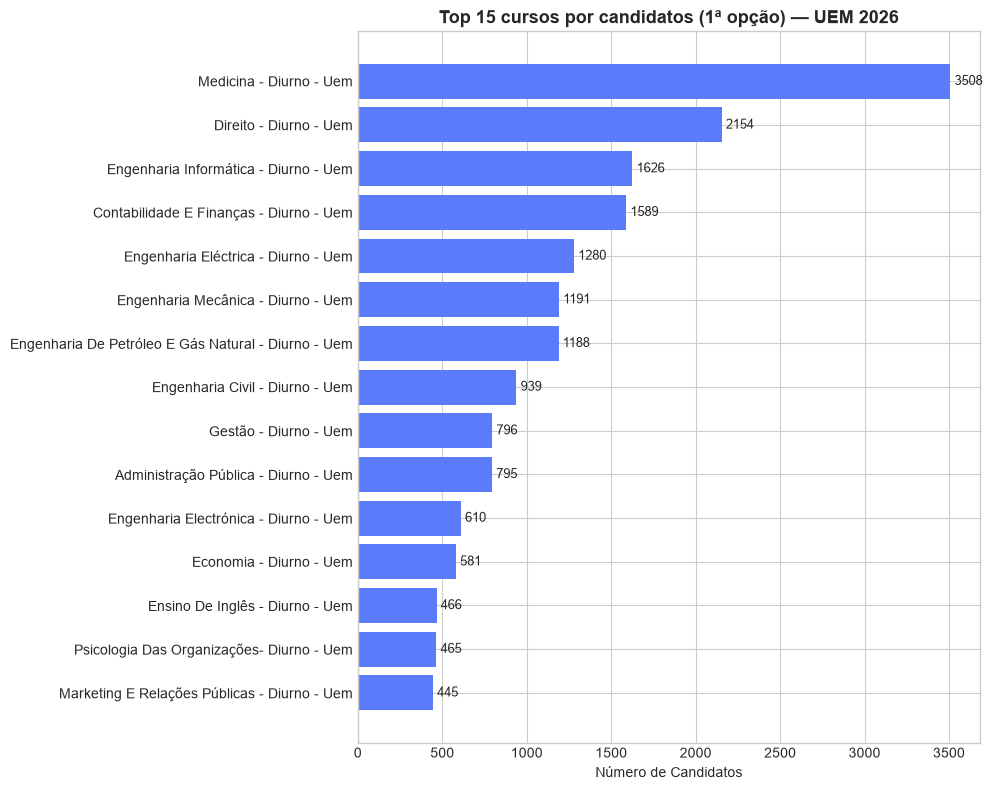

In [85]:
procura_opc1_top = procura_opc1.sort_values('candidatos_1a_opcao', ascending=True).tail(15).copy()

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    procura_opc1_top['curso'],
    procura_opc1_top['candidatos_1a_opcao'],
    color='#5B7CFA'
)

ax.set_title('Top 15 cursos por candidatos (1ª opção) — UEM 2026', fontsize=13, fontweight='bold')
ax.set_xlabel('Número de Candidatos')
ax.set_ylabel('')

for container in ax.containers:
    ax.bar_label(container, labels=[f'{v:g}' for v in container.datavalues], padding=3, fontsize=9)

plt.tight_layout()
plt.show()

In [86]:
#Dados de segunda opcao e dados combinados de curso
procura_opc2 = df_candidatos[df_candidatos['UEM_Opc2'] != 'Sem Opcao']['UEM_Opc2'].value_counts().reset_index()
procura_opc2.columns = ['curso', 'escolhas_2a_opcao']

procura_total = procura_opc1.rename(columns={'candidatos_1a_opcao': 'escolhas_1a_opcao'}).merge(
    procura_opc2, on='curso', how='outer'
).fillna(0)
procura_total['escolhas_1a_opcao'] = procura_total['escolhas_1a_opcao'].astype(int)
procura_total['escolhas_2a_opcao'] = procura_total['escolhas_2a_opcao'].astype(int)
procura_total['total_escolhas'] = procura_total['escolhas_1a_opcao'] + procura_total['escolhas_2a_opcao']
procura_total = procura_total.sort_values('total_escolhas', ascending=False)
procura_total.head(15)

,curso,escolhas_1a_opcao,escolhas_2a_opcao,total_escolhas
122,Medicina - Diurno - Uem,3508,170,3678
34,Direito - Diurno - Uem,2154,320,2474
63,Engenharia Informática - Diurno - Uem,1626,755,2381
30,Contabilidade E Finanças - Diurno - Uem,1589,614,2203
52,Engenharia De Petróleo E Gás Natural - Diurno ...,1188,935,2123
17,Biologia E Saúde - Diurno - Uem,409,1550,1959
60,Engenharia Eléctrica - Diurno - Uem,1280,678,1958
65,Engenharia Mecânica - Diurno - Uem,1191,564,1755
98,Gestão - Diurno - Uem,796,855,1651
0,Administração Pública - Diurno - Uem,795,847,1642


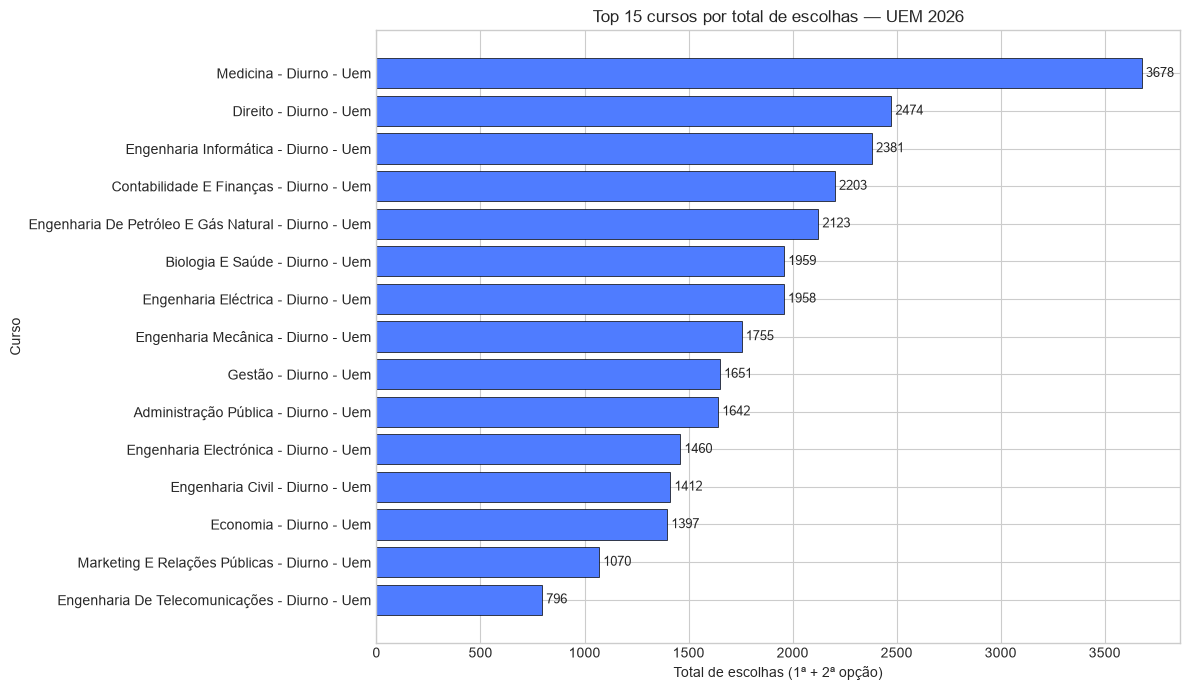

In [87]:
top15 = procura_total.head(15).copy()

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top15['curso'], top15['total_escolhas'], color='#4F7CFF', edgecolor='black', linewidth=0.5)
ax.invert_yaxis() 

ax.set_xlabel('Total de escolhas (1ª + 2ª opção)')
ax.set_ylabel('Curso')
ax.set_title('Top 15 cursos por total de escolhas — UEM 2026')

for container in ax.containers:
    ax.bar_label(container, labels=[f'{v:g}' for v in container.datavalues], padding=3, fontsize=9)

plt.tight_layout()
plt.show()

In [88]:
# Verificação de códigos oficiais e usados pelos candidatos
col_codigo = 'Código'
if col_codigo not in df_cursos.columns:
    raise KeyError(f'Coluna obrigatória ausente no cadastro: {col_codigo}')

codigos_oficiais = set(pd.to_numeric(df_cursos[col_codigo], errors='coerce').dropna().astype(int))
codigos_usados_opc1 = set(pd.to_numeric(df_candidatos['UEM_Cod_Opc1'], errors='coerce').dropna().astype(int))
codigos_usados_opc2 = set(pd.to_numeric(
    df_candidatos.loc[df_candidatos['UEM_Cod_Opc2'] != 0, 'UEM_Cod_Opc2'],
    errors='coerce'
).dropna().astype(int))

nao_reconhecidos = (codigos_usados_opc1 | codigos_usados_opc2) - codigos_oficiais
print(f'Códigos oficiais: {len(codigos_oficiais)}')
print(f'Códigos usados pelos candidatos: {len(codigos_usados_opc1 | codigos_usados_opc2)}')
print('Códigos usados por candidatos mas ausentes na lista oficial:')
if nao_reconhecidos:
    print(sorted(nao_reconhecidos))
    print('Cursos associados aos códigos ausentes:')
    print(df_candidatos.loc[
        df_candidatos['UEM_Cod_Opc1'].isin(nao_reconhecidos),
        ['UEM_Cod_Opc1', 'UEM_Opc1']
    ].drop_duplicates().to_string(index=False))
else:
    print('Nenhum código não reconhecido')

Códigos oficiais: 145
Códigos usados pelos candidatos: 145
Códigos usados por candidatos mas ausentes na lista oficial:
[11404]
Cursos associados aos códigos ausentes:
 UEM_Cod_Opc1                                    UEM_Opc1
        11404 Economia Agrária (Vilankulo) - Diurno - Uem


Candidatos por província de nascimento: ProvNasc
Cidade De Maputo       12404
Província De Maputo     5548
Gaza                    1991
Inhambane               1954
Zambezia                1249
Nampula                 1046
Sofala                   985
Manica                   541
Cabo Delgado             357
Tete                     317
Niassa                   286
Estrangeiro              119
Name: count, dtype: int64


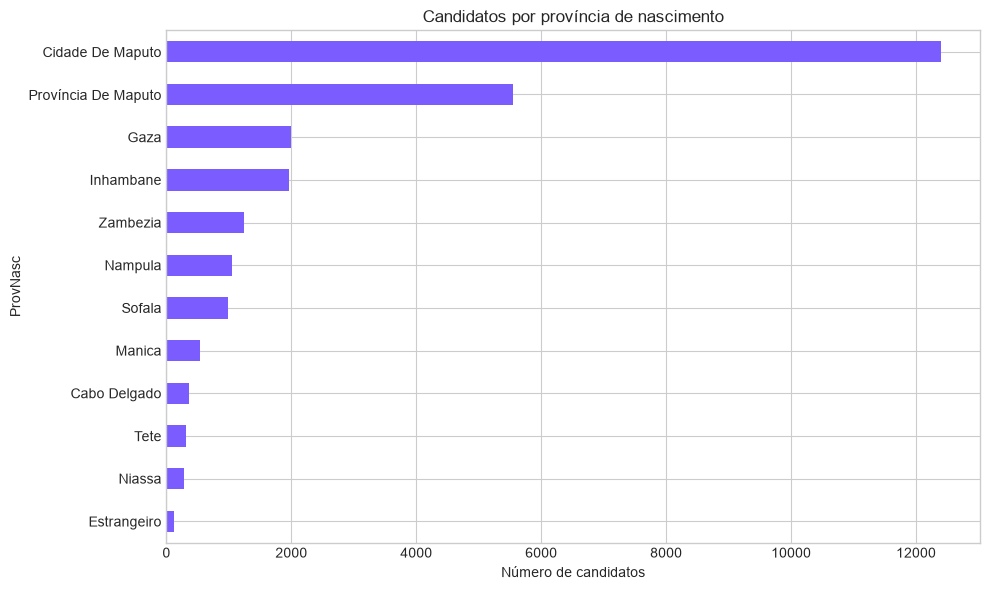

In [89]:
por_provincia = df_candidatos['ProvNasc'].value_counts()
print(f"Candidatos por província de nascimento: {por_provincia}")

plt.figure(figsize=(10, 6))
por_provincia.plot(kind='barh', color='#7B5CFF')
plt.gca().invert_yaxis()
plt.xlabel('Número de candidatos')
plt.title('Candidatos por província de nascimento')
plt.tight_layout()
plt.show()

In [90]:
print('Província de residência:')
print(df_candidatos['ProvRes'].value_counts())


Província de residência:
ProvRes
Cidade de Maputo       10957
Província de Maputo     9475
Gaza                    1478
Inhambane               1293
Nampula                  831
Zambezia                 738
Sofala                   668
Manica                   451
Tete                     352
Cabo Delgado             315
Niassa                   238
Estrangeiro                1
Name: count, dtype: int64


In [91]:
# Cruzamento de províncias: nascimento vs. residência
# Cada candidato é classificado como 'mesma província' ou 'província diferente'.
provincia_nascimento_chave = df_candidatos['ProvNasc'].map(chave_categoria)
provincia_residencia_chave = df_candidatos['ProvRes'].map(chave_categoria)
df_candidatos['migracao'] = provincia_nascimento_chave != provincia_residencia_chave
n_migrou = int(df_candidatos['migracao'].sum())
pct_migrou = n_migrou / len(df_candidatos) * 100

print('Cruzamento de províncias: nascimento x residência')
print(f'Candidatos que residem em província diferente da de nascimento: {n_migrou:,} ({pct_migrou:.1f}%)')
print('Interpretação: cada valor verdadeiro em migracao indica um candidato que concorre fora da sua província de nascimento.')

Cruzamento de províncias: nascimento x residência
Candidatos que residem em província diferente da de nascimento: 7,646 (28.5%)
Interpretação: cada valor verdadeiro em migracao indica um candidato que concorre fora da sua província de nascimento.


Matriz de cruzamento: província de nascimento x província de residência
Cada célula indica o número de candidatos que nasceram numa província e residem noutra.



Província de residência,,cabo delgado,cidade de maputo,estrangeiro,gaza,inhambane,manica,nampula,niassa,provincia de maputo,sofala,tete,zambezia
Província de nascimento,,,,,,,,,,,,,
,1,0,0,0,0,0,0,0,0,0,0,0,0
cabo delgado,0,232,53,0,0,5,2,15,4,40,1,3,2
cidade de maputo,0,14,"9,003",0,72,73,14,23,10,"3,116",26,36,17
estrangeiro,0,2,48,0,1,2,0,0,0,65,0,0,1
gaza,0,0,302,0,"1,295",17,6,5,2,352,8,3,1
inhambane,0,9,332,1,40,"1,111",6,4,2,421,11,8,9
manica,0,3,75,0,4,8,327,11,5,66,19,17,6
nampula,0,29,173,0,6,10,9,659,24,100,16,8,12
niassa,0,6,40,0,3,3,2,24,169,29,4,1,5



Candidatos que concorrem fora da sua província de residência: 7,646 (28.5%)
Distribuição por província de residência entre os candidatos que migraram:
ProvRes
Província de Maputo    4540
Cidade de Maputo       1954
Gaza                    183
Inhambane               182
Nampula                 172
Tete                    136
Manica                  124
Sofala                  123
Cabo Delgado             83
Zambezia                 79
Name: count, dtype: int64


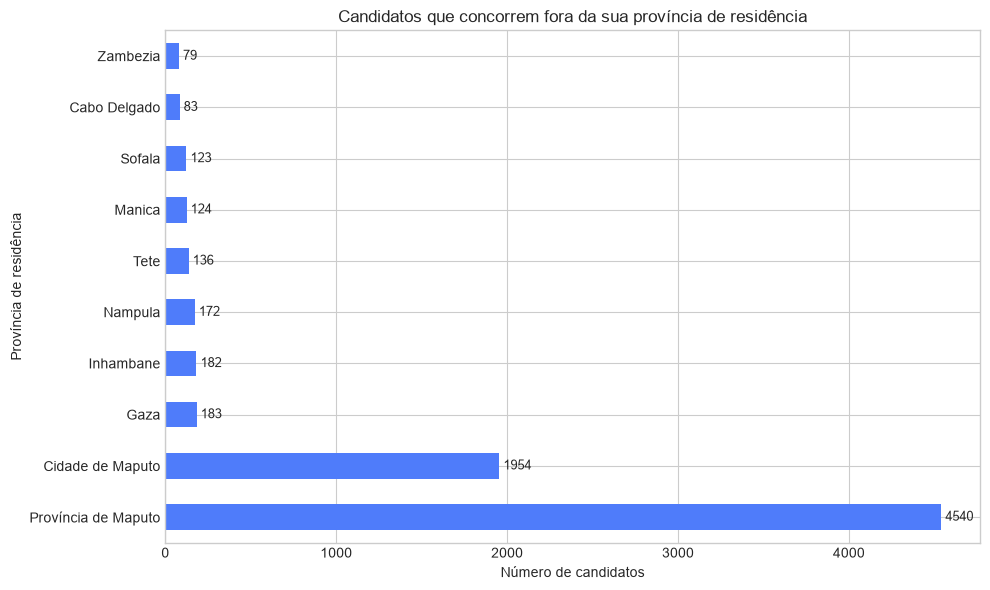

In [92]:
# Cruzamento de províncias: nascimento x residência
# Cada célula mostra quantos candidatos nasceram numa província e residem noutra.
cruzamento_prov = pd.crosstab(
    provincia_nascimento_chave.rename('Província de nascimento'),
    provincia_residencia_chave.rename('Província de residência'),
    dropna=False
)

fora_prov_residencia = df_candidatos[provincia_nascimento_chave != provincia_residencia_chave]

print('Matriz de cruzamento: província de nascimento x província de residência')
print('Cada célula indica o número de candidatos que nasceram numa província e residem noutra.')
print()
display(cruzamento_prov.style.background_gradient(cmap='Blues').format('{:,}'))
print()
print(f'Candidatos que concorrem fora da sua província de residência: {len(fora_prov_residencia):,} ({len(fora_prov_residencia) / len(df_candidatos) * 100:.1f}%)')
print('Distribuição por província de residência entre os candidatos que migraram:')
print(fora_prov_residencia['ProvRes'].value_counts().sort_values(ascending=False).head(10))

residencia_fora_prov = fora_prov_residencia['ProvRes'].value_counts().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
residencia_fora_prov.sort_values().plot(kind='barh', color='#4F7CFA', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Número de candidatos')
ax.set_ylabel('Província de residência')
ax.set_title('Candidatos que concorrem fora da sua província de residência')
for container in ax.containers:
    ax.bar_label(container, labels=[f'{v:g}' for v in container.datavalues], padding=3, fontsize=9)
plt.tight_layout()
plt.show()

Top 15 distritos de residência dos candidatos: distrito_residencia
Matola Cidade          6426
Kamubukwana            3212
Kamavota               3053
Kampfumo               1950
Kamaxaquene            1608
Marracuene             1519
Boane                   944
Kanlhamankulu           775
Cidade De Nampula       533
Cidade Da Beira         479
Cidade De Quelimane     435
Cidade De Xai-Xai       378
Xai-Xai                 314
Katembe                 302
Manhiça                 292
Name: count, dtype: int64


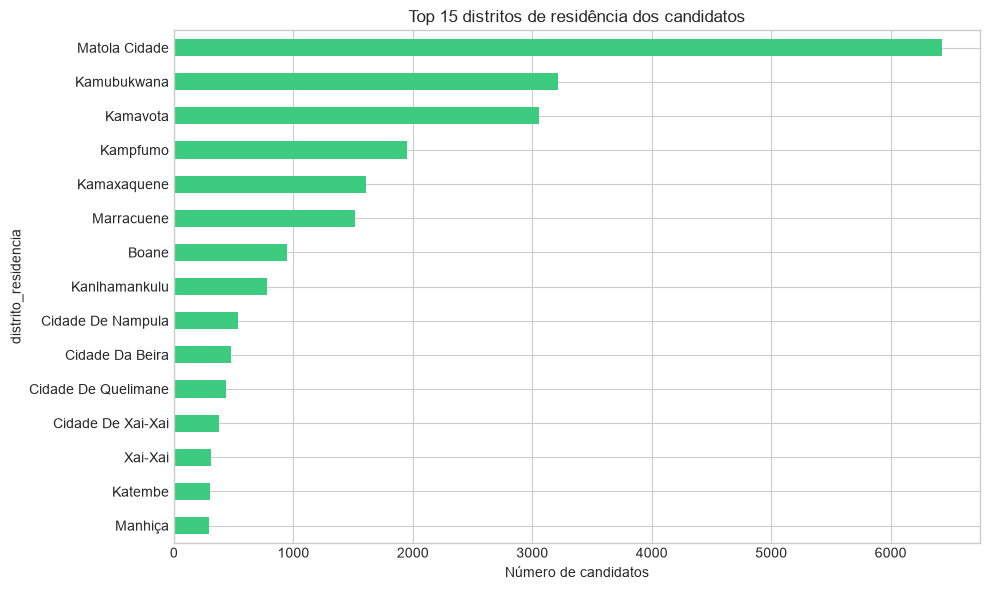

In [93]:
por_distrito = df_candidatos['distrito_residencia'].value_counts().head(15)
print(f"Top 15 distritos de residência dos candidatos: {por_distrito}")

plt.figure(figsize=(10, 6))
por_distrito.plot(kind='barh', color='#3CCB7F')
plt.gca().invert_yaxis()
plt.xlabel('Número de candidatos')
plt.title('Top 15 distritos de residência dos candidatos')
plt.tight_layout()
plt.show()

Candidatos estrangeiros: 119 (0.44%)


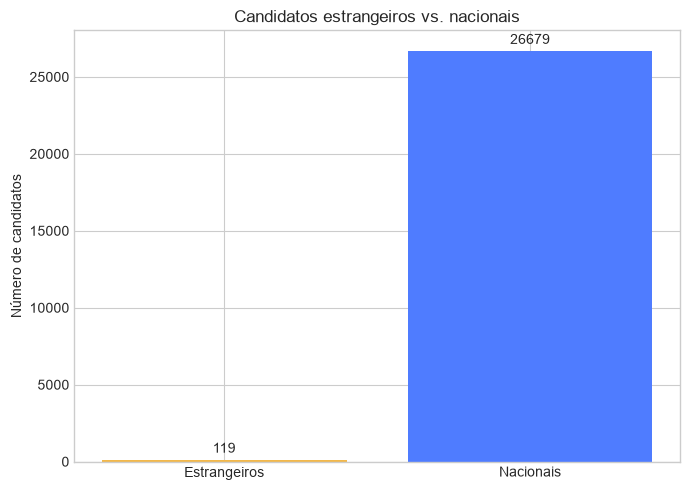

In [94]:
# Número de candidatos estrangeiros
n_estrangeiros = (df_candidatos['ProvNasc'] == 'Estrangeiro').sum()
pct_estrangeiros = n_estrangeiros / len(df_candidatos) * 100
print(f"Candidatos estrangeiros: {n_estrangeiros} ({pct_estrangeiros:.2f}%)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['Estrangeiros', 'Nacionais'], [n_estrangeiros, len(df_candidatos) - n_estrangeiros], color=['#F2B84B', '#4F7CFF'])
ax.set_title('Candidatos estrangeiros vs. nacionais')
ax.set_ylabel('Número de candidatos')
for container in ax.containers:
    ax.bar_label(container, labels=[f'{v:g}' for v in container.datavalues], padding=3, fontsize=10)
plt.tight_layout()
plt.show()



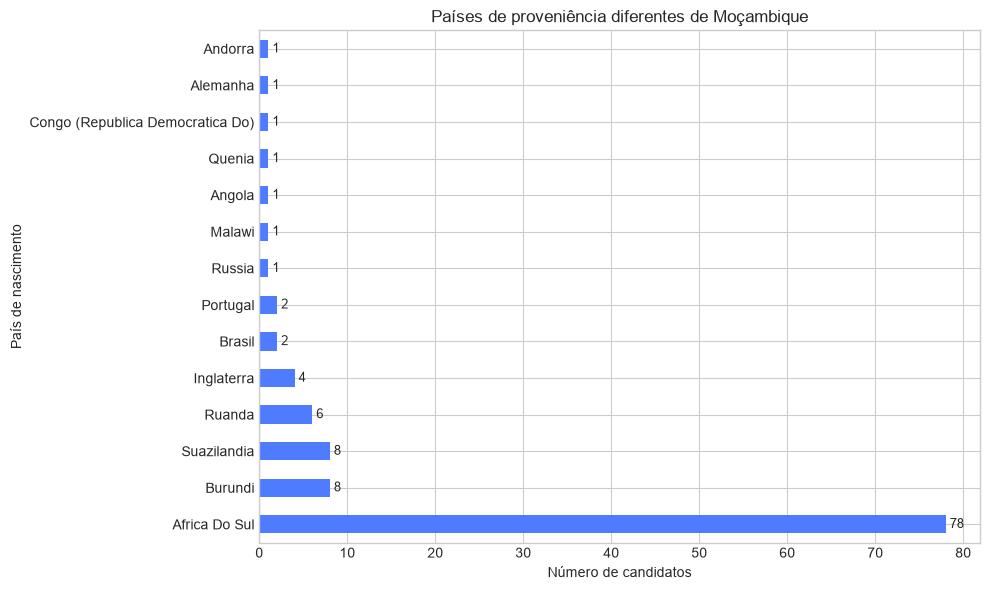

In [96]:
fig, ax = plt.subplots(figsize=(10, 6))
pais_outra_provincia.plot(kind='barh', color='#4F7CFF', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Número de candidatos')
ax.set_ylabel('País de nascimento')
ax.set_title('Países de proveniência diferentes de Moçambique')

for container in ax.containers:
    ax.bar_label(container, labels=[f'{v:g}' for v in container.datavalues], padding=3, fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# cursos mais procurados especificamente por candidatos estrangeiros
df_candidatos[df_candidatos['ProvNasc'] == 'Estrangeiro']['UEM_Opc1'].value_counts().head(10)

UEM_Opc1
Medicina - Diurno - Uem                    13
Direito - Diurno - Uem                     12
Engenharia Mecânica - Diurno - Uem          9
Engenharia Informática - Diurno - Uem       8
Engenharia Química - Diurno - Uem           6
Gestão - Diurno - Uem                       5
Biologia E Saúde - Diurno - Uem             5
Contabilidade E Finanças - Diurno - Uem     5
Economia - Diurno - Uem                     4
Administração Pública - Diurno - Uem        3
Name: count, dtype: int64

## Demografia — sexo, estado civil, idade

In [ ]:
print(df_candidatos['Sexo'].value_counts())
print()
print(df_candidatos['EstCivil'].value_counts())

Sexo
Feminino     15580
Masculino    11217
Name: count, dtype: int64

EstCivil
Solteiro(A)      26541
Casado(A)          242
Divorciado(A)       10
Viúvo(A)             4
Name: count, dtype: int64


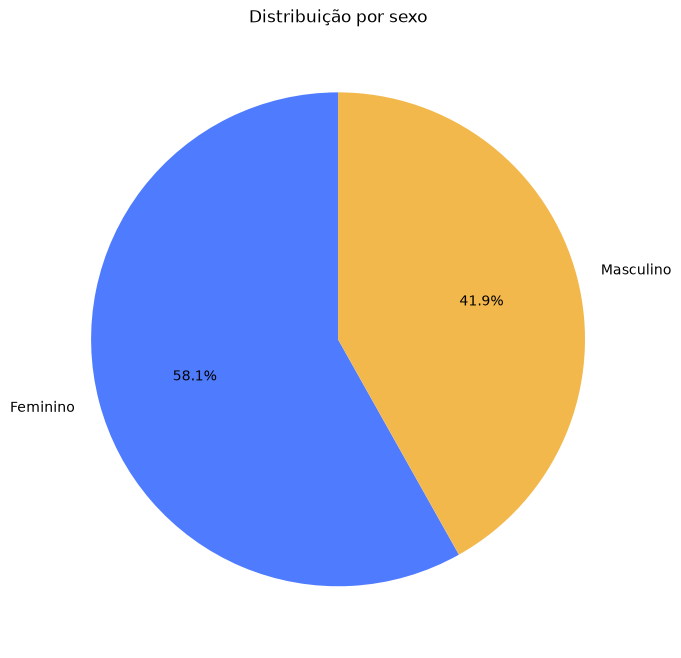

In [ ]:
sexo_counts = df_candidatos['Sexo'].fillna('Não indicado').value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    sexo_counts.values,
    labels=sexo_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4F7CFF', '#F2B84B', '#7B5CFF', '#3CCB7F', '#FF7F50'],
)
ax.set_title('Distribuição por sexo')
plt.tight_layout()
plt.show()

In [ ]:
df_candidatos['idade'] = 2026 - pd.to_datetime(df_candidatos['data_Nasc']).dt.year
print(df_candidatos['idade'].describe())


count    26797.000000
mean        20.807255
std          4.076333
min         15.000000
25%         18.000000
50%         20.000000
75%         22.000000
max         64.000000
Name: idade, dtype: float64


## Cruzamento entre a idade e o curso escolhido. 

In [ ]:
# faixas etárias 
bins = [0, 18, 21, 24, 27, 30, 35, 150]
labels = ['≤18', '19-21', '22-24', '25-27', '28-30', '31-35', '36+']

df_candidatos['faixa_etaria'] = pd.cut(
    df_candidatos['idade'],
    bins=bins,
    labels=labels,
    right=True
)

# Tabela cruzada: curso x faixa etária
idade_por_curso_faixas = pd.crosstab(
    df_candidatos['UEM_Opc1'],
    df_candidatos['faixa_etaria']
)

idade_por_curso_faixas['total'] = idade_por_curso_faixas.sum(axis=1)
idade_por_curso_faixas = idade_por_curso_faixas.sort_values('total', ascending=False).drop(columns='total')

idade_por_curso_faixas.head(20)

faixa_etaria,≤18,19-21,22-24,25-27,28-30,31-35,36+
UEM_Opc1,,,,,,,
Medicina - Diurno - Uem,1267,1535,341,114,88,113,49
Direito - Diurno - Uem,694,1048,235,69,38,34,36
Engenharia Informática - Diurno - Uem,669,800,116,27,9,4,1
Contabilidade E Finanças - Diurno - Uem,440,876,197,44,20,9,3
Engenharia Eléctrica - Diurno - Uem,430,649,151,36,6,6,2
Engenharia Mecânica - Diurno - Uem,445,605,107,18,9,5,2
Engenharia De Petróleo E Gás Natural - Diurno - Uem,557,481,83,28,11,13,15
Engenharia Civil - Diurno - Uem,352,498,66,15,2,4,2
Gestão - Diurno - Uem,181,441,128,27,10,4,5


In [ ]:
idade_estrangeiros = df_candidatos[df_candidatos['ProvNasc'] == 'Estrangeiro']['idade']
print("Idade dos candidatos estrangeiros:")
print(idade_estrangeiros.describe())
print()
print("Comparação com candidatos nacionais:")
print(df_candidatos[df_candidatos['ProvNasc'] != 'Estrangeiro']['idade'].describe())

Idade dos candidatos estrangeiros:
count    119.000000
mean      20.252101
std        2.867759
min       15.000000
25%       19.000000
50%       19.000000
75%       21.000000
max       36.000000
Name: idade, dtype: float64

Comparação com candidatos nacionais:
count    26678.000000
mean        20.809731
std          4.080791
min         15.000000
25%         18.000000
50%         20.000000
75%         22.000000
max         64.000000
Name: idade, dtype: float64


In [ ]:

df_estrangeiros = df_candidatos[df_candidatos['pais_nascimento'] != 'Mocambique'].copy()
bins = [0, 18, 21, 24, 27, 30, 35, 150]
labels = ['≤18', '19-21', '22-24', '25-27', '28-30', '31-35', '36+']

df_estrangeiros['faixa_etaria'] = pd.cut(
    df_estrangeiros['idade'],
    bins=bins,
    labels=labels,
    right=True
)

estrangeiros_por_faixa = df_estrangeiros['faixa_etaria'].value_counts().sort_index()
estrangeiros_por_faixa

faixa_etaria
≤18      28
19-21    68
22-24    13
25-27     7
28-30     1
31-35     1
36+       1
Name: count, dtype: int64

In [ ]:
estrangeiros_por_curso_faixa = pd.crosstab(
    df_estrangeiros['UEM_Opc1'],
    df_estrangeiros['faixa_etaria']
)

estrangeiros_por_curso_faixa['total'] = estrangeiros_por_curso_faixa.sum(axis=1)
estrangeiros_por_curso_faixa = estrangeiros_por_curso_faixa.sort_values('total', ascending=False).drop(columns='total')

estrangeiros_por_curso_faixa.head(20)

faixa_etaria,≤18,19-21,22-24,25-27,28-30,31-35,36+
UEM_Opc1,,,,,,,
Medicina - Diurno - Uem,4,7,1,0,0,1,0
Direito - Diurno - Uem,2,8,1,1,0,0,0
Engenharia Mecânica - Diurno - Uem,2,6,1,0,0,0,0
Engenharia Informática - Diurno - Uem,3,4,1,0,0,0,0
Engenharia Química - Diurno - Uem,2,4,0,0,0,0,0
Biologia E Saúde - Diurno - Uem,1,4,0,0,0,0,0
Gestão - Diurno - Uem,0,5,0,0,0,0,0
Contabilidade E Finanças - Diurno - Uem,4,1,0,0,0,0,0
Economia - Diurno - Uem,0,3,1,0,0,0,0


## Cruzamento — género por curso (top 10 mais procurados)

In [ ]:
top10_cursos = procura_total.head(10)['curso'].tolist()
cruzamento_genero = df_candidatos[df_candidatos['UEM_Opc1'].isin(top10_cursos)].groupby(['UEM_Opc1', 'Sexo']).size().unstack(fill_value=0)
cruzamento_genero['%_feminino'] = (cruzamento_genero.get('Feminino', 0) /
                                     cruzamento_genero.sum(axis=1) * 100).round(1)
cruzamento_genero.sort_values('%_feminino')

Sexo,Feminino,Masculino,%_feminino
UEM_Opc1,,,
Engenharia Mecânica - Diurno - Uem,318,873,26.7
Engenharia Informática - Diurno - Uem,461,1165,28.4
Engenharia Eléctrica - Diurno - Uem,412,868,32.2
Engenharia De Petróleo E Gás Natural - Diurno - Uem,619,569,52.1
Contabilidade E Finanças - Diurno - Uem,1059,530,66.6
Gestão - Diurno - Uem,577,219,72.5
Direito - Diurno - Uem,1576,578,73.2
Medicina - Diurno - Uem,2652,855,75.6
Administração Pública - Diurno - Uem,620,175,78.0


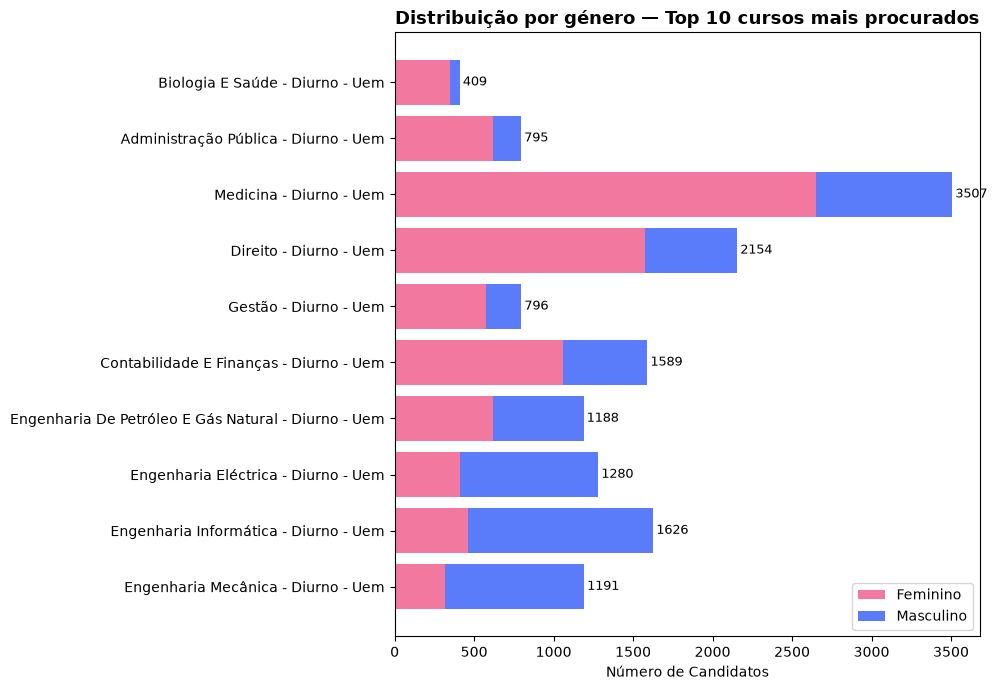

In [ ]:
cruzamento_plot = cruzamento_genero.sort_values('%_feminino', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    cruzamento_plot.index,
    cruzamento_plot['Feminino'],
    color='#F2789F',
    label='Feminino'
)
ax.barh(
    cruzamento_plot.index,
    cruzamento_plot['Masculino'],
    left=cruzamento_plot['Feminino'],
    color='#5B7CFA',
    label='Masculino'
)

ax.set_title('Distribuição por género — Top 10 cursos mais procurados', fontsize=13, fontweight='bold')
ax.set_xlabel('Número de Candidatos')
ax.set_ylabel('')
ax.legend(loc='lower right')

for i, curso in enumerate(cruzamento_plot.index):
    total = cruzamento_plot.loc[curso, 'Feminino'] + cruzamento_plot.loc[curso, 'Masculino']
    ax.text(total + 20, i, f'{int(total)}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
print("Top 20 escolas por número de candidatos:")
df_candidatos['EscoPU'].value_counts().head(20)

Top 20 escolas por número de candidatos:


EscoPU
Outra - Província De Maputo                     2396
Desconhecida - Cidade De Maputo                 2244
Outra - Cidade De Maputo                         864
Escola Secundária De Machava Sede                809
Desconhecida - Província De Maputo               803
Escola Secundária Da Zona-Verde                  644
Escola Secundária Bonifácio Gruveta Massamba     643
Escola Secundária De Laulane                     599
Escola Secundária Noroeste 1                     592
Escola Secundária Heróis Moçambicanos            588
Escola Secundária Quisse Mavota                  587
Escola Secundária Da Matola                      573
Escola Secundária Joaquim Alberto Chissano       547
Escola Secundária Francisco Manyanga             537
Escola Secundária Eduardo Mondlane               535
Escola Secundária Da Liberdade                   497
Escola Secundária De Malhazine                   450
Escola Secundária De Nkobe                       439
Escola Secundária Força Do Povo        

In [ ]:
# para os top 5 cursos mais procurados, quais as 3 escolas que mais alimentam cada um
top5_cursos = procura_total.head(5)['curso'].tolist()
for curso in top5_cursos:
    print(f"\n{curso}:")
    print(df_candidatos[df_candidatos['UEM_Opc1'] == curso]['EscoPU'].value_counts().head(3))


Medicina - Diurno - Uem:
EscoPU
Outra - Província De Maputo           300
Desconhecida - Cidade De Maputo       242
Desconhecida - Província De Maputo     99
Name: count, dtype: int64

Direito - Diurno - Uem:
EscoPU
Outra - Província De Maputo              206
Desconhecida - Cidade De Maputo          204
Escola Secundária Heróis Moçambicanos     73
Name: count, dtype: int64

Engenharia Informática - Diurno - Uem:
EscoPU
Desconhecida - Cidade De Maputo    174
Outra - Província De Maputo        156
Outra - Cidade De Maputo            69
Name: count, dtype: int64

Contabilidade E Finanças - Diurno - Uem:
EscoPU
Desconhecida - Cidade De Maputo    172
Outra - Província De Maputo        157
Outra - Cidade De Maputo            77
Name: count, dtype: int64

Engenharia De Petróleo E Gás Natural - Diurno - Uem:
EscoPU
Outra - Província De Maputo        91
Desconhecida - Cidade De Maputo    77
Outra - Cidade De Maputo           44
Name: count, dtype: int64


In [ ]:
print(df_candidatos['AnocPU'].value_counts().sort_index(ascending=False).head(15))

n_direto = (df_candidatos['AnocPU'] == 2025).sum()
pct_direto = n_direto / len(df_candidatos) * 100
print(f"\nCandidatos vindos direto do secundário (concluído em 2025): {n_direto} ({pct_direto:.1f}%)")

AnocPU
2025    11345
2024     6920
2023     3263
2022     1525
2021     1278
2020      495
2019      477
2018      407
2017      198
2016      184
2015      122
2014       75
2013      104
2012       90
2011       74
Name: count, dtype: int64

Candidatos vindos direto do secundário (concluído em 2025): 11345 (42.3%)


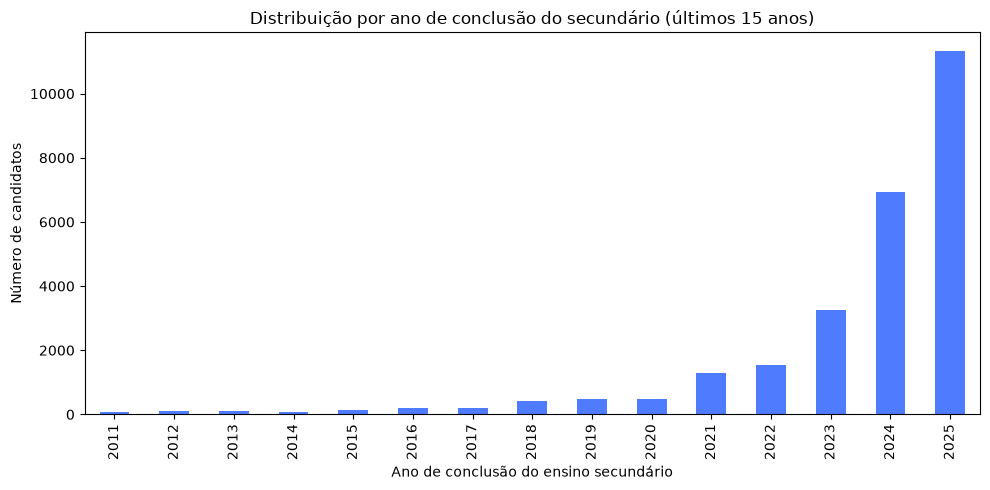

In [ ]:
plt.figure(figsize=(10, 5))
df_candidatos['AnocPU'].value_counts().sort_index().tail(15).plot(kind='bar', color='#4F7CFF')
plt.xlabel('Ano de conclusão do ensino secundário')
plt.ylabel('Número de candidatos')
plt.title('Distribuição por ano de conclusão do secundário (últimos 15 anos)')
plt.tight_layout()
plt.show()

In [ ]:
print("Top 15 locais de exame:")
print(df_candidatos['local_exame'].value_counts().head(15))

# candidatos onde o local de exame é diferente do distrito de residência 
deslocados = (df_candidatos['local_exame'].str.strip().str.title() != df_candidatos['distrito_residencia'].str.strip().str.title()).sum()
pct_deslocados = deslocados / len(df_candidatos) * 100
print(f"\nCandidatos com local de exame diferente do distrito de residência: {deslocados} ({pct_deslocados:.1f}%)")


Top 15 locais de exame:
local_exame
Cidade De Maputo       15936
Província De Maputo     4563
Chongoene               1044
Cidade De Nampula        837
Cidade Da Beira          669
Cidade De Quelimane      586
Maxixe                   512
Cidade De Inhambane      504
Cidade De Chimoio        448
Chibuto                  428
Cidade De Tete           362
Cidade De Pemba          321
Cidade De Lichinga       247
Vilankulo                227
Mocuba                   112
Name: count, dtype: int64

Candidatos com local de exame diferente do distrito de residência: 24554 (91.6%)


AVISO: 1 datas de nascimento inválidas foram ignoradas no cálculo de idade.
AVISO: códigos ausentes no cadastro oficial: [11404]
Validações concluídas. Tabelas e gráficos principais guardados.


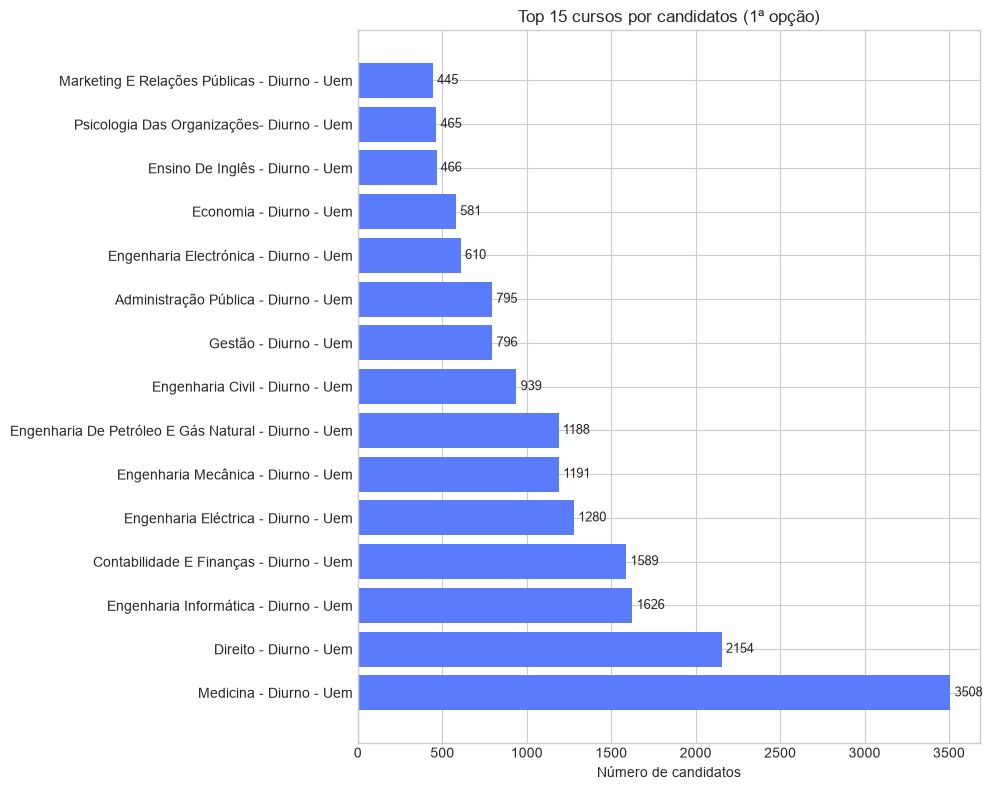

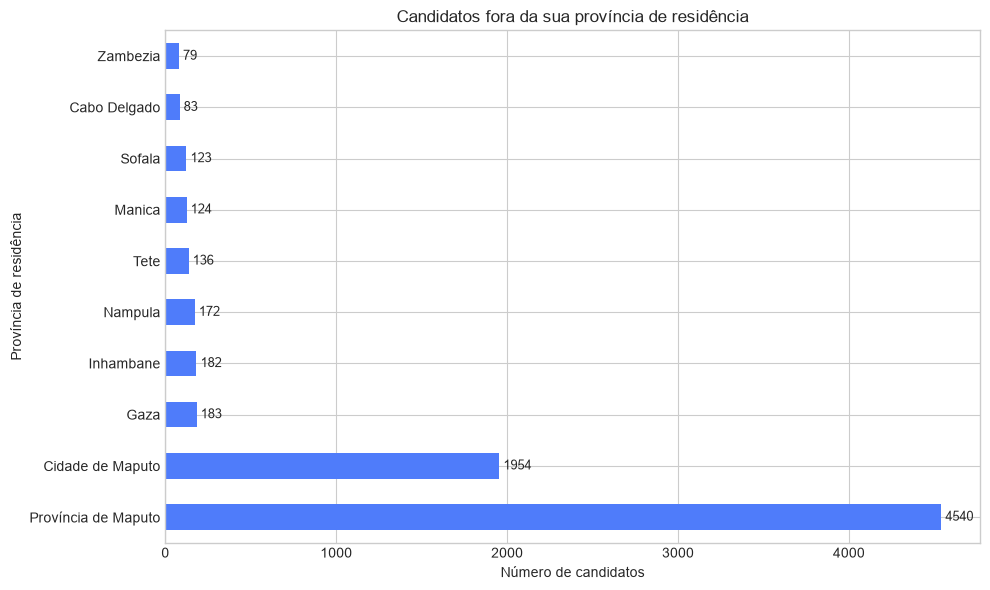

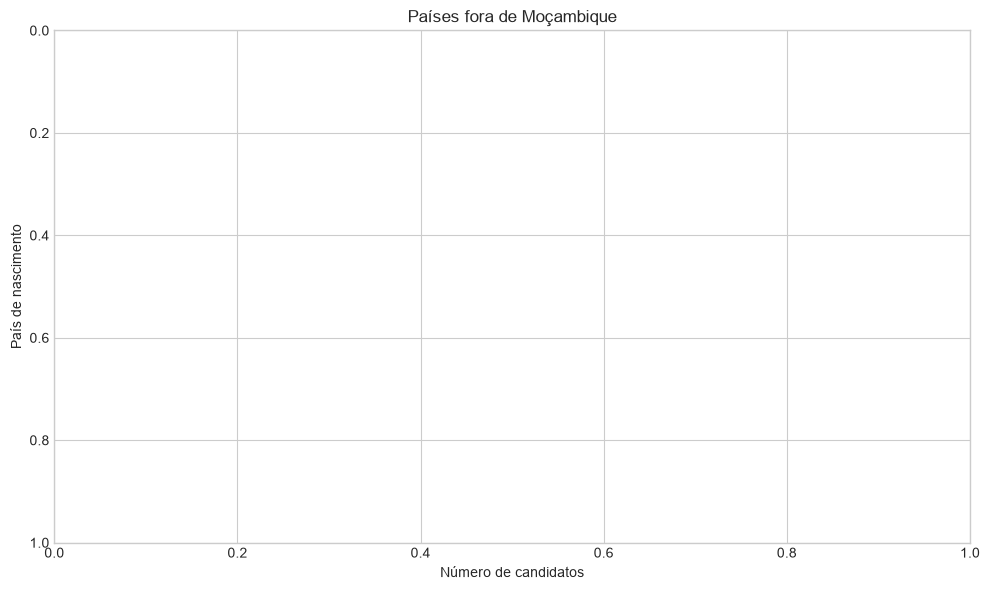

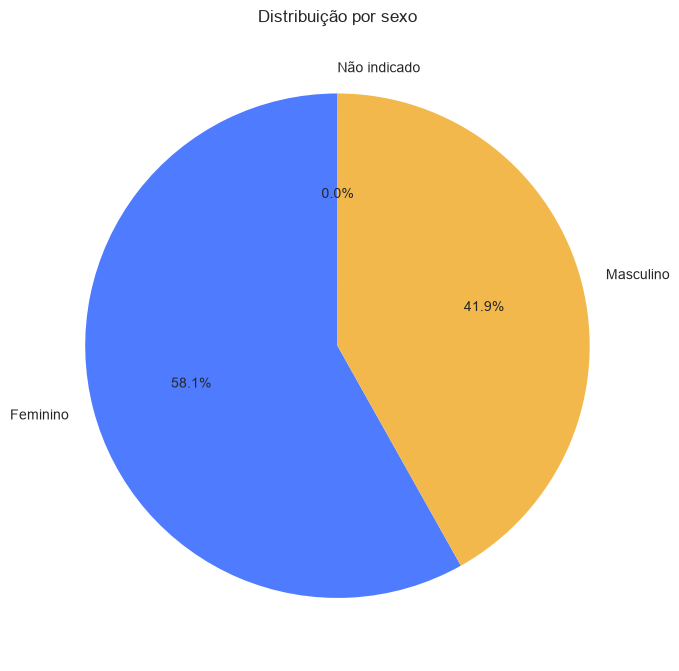

In [98]:
datas_nascimento = pd.to_datetime(df_candidatos['data_Nasc'], errors='coerce')
segundo_opcao = df_candidatos['UEM_Opc2'].ne('Sem Opcao')

n_datas_invalidas = datas_nascimento.isna().sum()
if n_datas_invalidas:
    print(f'AVISO: {n_datas_invalidas} datas de nascimento inválidas foram ignoradas no cálculo de idade.')

if 'idade' not in df_candidatos.columns:
    df_candidatos['idade'] = 2026 - pd.to_datetime(df_candidatos['data_Nasc'], errors='coerce').dt.year

assert len(df_candidatos) > 0
assert df_candidatos['UEM_Cod_Opc1'].notna().all(), 'Existem códigos ausentes na primeira opção.'

soma_escolhas = procura_total['total_escolhas'].sum()
valor_esperado = len(df_candidatos) + int(segundo_opcao.sum())
if soma_escolhas != valor_esperado:
    print(f'AVISO: soma de escolhas ({soma_escolhas}) difere do esperado ({valor_esperado}).')

assert df_candidatos['idade'].dropna().between(15, 100).all(), 'Existem idades fora do intervalo esperado.'

if cruzamento_prov.to_numpy().sum() != len(df_candidatos):
    print(f'AVISO: total do cruzamento de províncias ({cruzamento_prov.to_numpy().sum()}) difere do número de candidatos ({len(df_candidatos)}).')

if nao_reconhecidos:
    print(f'AVISO: códigos ausentes no cadastro oficial: {sorted(nao_reconhecidos)}')

# Resumo de países fora de Moçambique
pais_normalizado_final = df_candidatos['pais_nascimento'].fillna('').astype(str).apply(normalizar_texto)
mask_excluir_pais = pais_normalizado_final.str.contains(
    'mocambique|mozambique|moz|estrangeiro|nao indicada|desconhecida',
    case=False,
    na=False,
)

df_paises = (
    df_candidatos.loc[~mask_excluir_pais, 'pais_nascimento']
    .value_counts()
    .reset_index()
)
df_paises.columns = ['pais', 'candidatos']

# Exportação de tabelas-resumo
exportar_csv(procura_total, 'resumo_procura_por_curso.csv', index=False)
exportar_csv(por_provincia, 'resumo_por_provincia.csv')
exportar_csv(por_distrito, 'resumo_por_distrito.csv')
exportar_csv(df_paises, 'resumo_por_pais.csv', index=False)
exportar_csv(cruzamento_genero, 'resumo_genero_por_curso.csv')
exportar_csv(df_candidatos['EscoPU'].value_counts(), 'resumo_por_escola.csv')
exportar_csv(df_candidatos['AnocPU'].value_counts(), 'resumo_por_ano_conclusao.csv')
exportar_csv(cruzamento_prov, 'resumo_migracao_provincia.csv')
exportar_csv(idade_estrangeiros, 'resumo_idade_estrangeiros.csv')

# Gráficos principais para arquivo
fig, ax = plt.subplots(figsize=(10, 8))
procura_opc1_top = procura_opc1.sort_values('candidatos_1a_opcao', ascending=True).tail(15).copy()
ax.barh(procura_opc1_top['curso'], procura_opc1_top['candidatos_1a_opcao'], color='#5B7CFA')
ax.invert_yaxis()
ax.set_title('Top 15 cursos por candidatos (1ª opção)')
ax.set_xlabel('Número de candidatos')
for container in ax.containers:
    ax.bar_label(container, labels=[f'{v:g}' for v in container.datavalues], padding=3, fontsize=9)
plt.tight_layout()
salvar_grafico(fig, 'grafico_procura_top15.png')

fig, ax = plt.subplots(figsize=(10, 6))
residencia_fora_prov = fora_prov_residencia['ProvRes'].value_counts().sort_values(ascending=False).head(10)
residencia_fora_prov.sort_values().plot(kind='barh', color='#4F7CFA', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Número de candidatos')
ax.set_ylabel('Província de residência')
ax.set_title('Candidatos fora da sua província de residência')
for container in ax.containers:
    ax.bar_label(container, labels=[f'{v:g}' for v in container.datavalues], padding=3, fontsize=9)
plt.tight_layout()
salvar_grafico(fig, 'grafico_migracao_provincia.png')

fig, ax = plt.subplots(figsize=(10, 6))

ax.invert_yaxis()
ax.set_xlabel('Número de candidatos')
ax.set_ylabel('País de nascimento')
ax.set_title('Países fora de Moçambique')
for container in ax.containers:
    ax.bar_label(container, labels=[f'{v:g}' for v in container.datavalues], padding=3, fontsize=9)
plt.tight_layout()
salvar_grafico(fig, 'grafico_paises_fora_mocambique.png')

fig, ax = plt.subplots(figsize=(7, 7))
sexo_counts = df_candidatos['Sexo'].fillna('Não indicado').value_counts().sort_values(ascending=False)
ax.pie(
    sexo_counts.values,
    labels=sexo_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4F7CFF', '#F2B84B', '#7B5CFF', '#3CCB7F', '#FF7F50'],
)
ax.set_title('Distribuição por sexo')
plt.tight_layout()
salvar_grafico(fig, 'grafico_sexo.png')



print('Validações concluídas. Tabelas e gráficos principais guardados.')